# 0823_kimjaehak_002_temporal_drift

> EDA 001에서 확인한 132일 시계열의 분포 변화를 정량화합니다. 실제 행이나 불필요한 고유값은 출력하지 않고 집계 결과만 사용합니다.

## 분석 배경과 질문

원 논문은 생산환경 변화나 AOI 프로그램 수정으로 인해 시점과 원인이 알려지지 않은 distribution drift가 존재할 수 있다고 명시합니다. 또한 동일 timestamp는 같은 PCB의 여러 검사 지점을 묶는 대리 그룹이므로 분할 경계에서 함께 보존해야 합니다.

이 노트북은 다음 질문에 답합니다.

1. 일별·주별 물량과 true-defect 비율은 시간에 따라 어떻게 변하는가?
2. `inspection_type` 구성비는 시간에 따라 변하는가?
3. 동일 timestamp 그룹을 보존한 시간순 60/20/20 분할의 경계와 분포는 어떠한가?
4. 검사유형별 매핑 유효·비상수 피처의 첫 구간(train) 대비 마지막 구간(test) PSI는 어느 정도인가?

## 1. 설정과 라이브러리

저장소 루트와 노트북 디렉터리 어디에서 실행해도 원본 파일을 찾도록 경로를 결정합니다. 원본 파일은 읽기만 하며 수정하지 않습니다.

In [1]:
from pathlib import Path
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

EXPERIMENT_ID = "0823_kimjaehak_002_temporal_drift"
RANDOM_STATE = 42
SPLIT_TARGETS = (0.60, 0.80)
PSI_BINS = 10
PSI_EPSILON = 1e-6

candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (path for path in candidate_roots if (path / "data/raw/dataset.csv").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("data/raw/dataset.csv를 찾을 수 없습니다. 저장소 루트에서 실행하세요.")

DATA_PATH = REPO_ROOT / "data/raw/dataset.csv"
MAPPING_PATH = REPO_ROOT / "data/raw/mapping.json"
PAPER_PATH = REPO_ROOT / "docs/1-s2.0-S2352340924000830-main.pdf"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("experiment:", EXPERIMENT_ID)
print("python:", platform.python_version())
print("pandas:", pd.__version__)
print("random state:", RANDOM_STATE)
print("data file exists:", DATA_PATH.exists())
print("mapping file exists:", MAPPING_PATH.exists())
print("paper file exists:", PAPER_PATH.exists())

experiment: 0823_kimjaehak_002_temporal_drift
python: 3.12.13
pandas: 3.0.5
random state: 42
data file exists: True
mapping file exists: True
paper file exists: True


## 2. 데이터 로딩과 시간축 준비

CSV의 첫 열은 `record_id`로 이름만 바꾸고 모델 입력이나 PSI에 사용하지 않습니다. timestamp는 UTC로 파싱하며 파싱 실패가 없는지 검증합니다.

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
with MAPPING_PATH.open(encoding="utf-8") as stream:
    mapping = json.load(stream)

source_index_column = df.columns[0]
if source_index_column.startswith("Unnamed:"):
    df = df.rename(columns={source_index_column: "record_id"})
elif source_index_column != "record_id":
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

TARGET = "class"
TYPE_COLUMN = "inspection_type"
TIME_COLUMN = "timestamp"
PARSED_TIME = "parsed_timestamp"
INSPECTION_COLUMNS = [column for column in df.columns if column.startswith("inspection_feat")]

df[PARSED_TIME] = pd.to_datetime(df[TIME_COLUMN], errors="coerce", utc=True)
assert df[PARSED_TIME].notna().all(), "timestamp 파싱 실패가 있습니다."
assert sorted(df[TYPE_COLUMN].unique().tolist()) == sorted(int(key) for key in mapping)
assert all(set(columns).issubset(INSPECTION_COLUMNS) for columns in mapping.values())

time_axis_summary = pd.Series(
    {
        "rows": len(df),
        "first_timestamp": df[PARSED_TIME].min(),
        "last_timestamp": df[PARSED_TIME].max(),
        "span_days": int((df[PARSED_TIME].max() - df[PARSED_TIME].min()).days),
        "active_days": int(df[PARSED_TIME].dt.floor("D").nunique()),
        "unique_timestamp_groups": int(df[PARSED_TIME].nunique()),
    },
    name="value",
)
display(time_axis_summary.to_frame())

,value
rows,440274
first_timestamp,1970-06-23 03:58:55+00:00
last_timestamp,1970-11-02 14:21:28+00:00
span_days,132
active_days,101
unique_timestamp_groups,39742


## 3. 동일 timestamp 그룹을 보존한 시간순 60/20/20 분할

timestamp 그룹을 오름차순으로 정렬한 뒤 누적 행 수가 전체의 60%, 80%에 가장 가까운 그룹 끝을 경계로 선택합니다. 경계 그룹 전체를 앞 구간에 포함하므로 실제 행 비율은 목표와 미세하게 다를 수 있지만 동일 timestamp가 여러 구간에 섞이지 않습니다.

In [3]:
timestamp_group_sizes = df.groupby(PARSED_TIME, sort=True).size()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def nearest_group_end(target_rows):
    insertion = int(np.searchsorted(cumulative_rows, target_rows))
    candidates = np.unique(
        np.clip([insertion - 1, insertion], 0, len(cumulative_rows) - 1)
    )
    return int(candidates[np.argmin(np.abs(cumulative_rows[candidates] - target_rows))])

train_end_position = nearest_group_end(SPLIT_TARGETS[0] * len(df))
validation_end_position = nearest_group_end(SPLIT_TARGETS[1] * len(df))
assert train_end_position < validation_end_position

train_end = timestamp_group_sizes.index[train_end_position]
validation_end = timestamp_group_sizes.index[validation_end_position]
split_labels = np.select(
    [df[PARSED_TIME] <= train_end, df[PARSED_TIME] <= validation_end],
    ["train", "validation"],
    default="test",
)
df["split"] = pd.Categorical(
    split_labels, categories=["train", "validation", "test"], ordered=True
)

timestamp_split_counts = df.groupby(PARSED_TIME, observed=True)["split"].nunique()
assert int(timestamp_split_counts.max()) == 1, "동일 timestamp가 여러 split에 포함되었습니다."
assert int(df.groupby("split", observed=False).size().sum()) == len(df)

split_summary = df.groupby("split", observed=False).agg(
    rows=(TARGET, "size"),
    timestamp_groups=(PARSED_TIME, "nunique"),
    start=(PARSED_TIME, "min"),
    end=(PARSED_TIME, "max"),
    true_defects=(TARGET, "sum"),
    defect_rate=(TARGET, "mean"),
)
split_summary["row_share_pct"] = split_summary["rows"] / len(df) * 100
split_summary["defect_rate_pct"] = split_summary["defect_rate"] * 100
display(
    split_summary[
        ["rows", "row_share_pct", "timestamp_groups", "start", "end", "true_defects", "defect_rate_pct"]
    ]
)
print("timestamp groups crossing split boundaries:", int((timestamp_split_counts > 1).sum()))

,rows,row_share_pct,timestamp_groups,start,end,true_defects,defect_rate_pct
split,,,,,,,
train,264343,60.0406,26063,1970-06-23 03:58:55+00:00,1970-09-28 05:10:37+00:00,1901,0.7191
validation,87879,19.9601,6586,1970-09-28 05:11:13+00:00,1970-10-13 16:54:14+00:00,396,0.4506
test,88052,19.9994,7093,1970-10-13 16:54:52+00:00,1970-11-02 14:21:28+00:00,2325,2.6405


timestamp groups crossing split boundaries: 0


## 4. 일별·주별 물량과 true-defect 비율

일별 변동과 주별 추세를 함께 봅니다. 주는 월요일 시작으로 집계하며, 연도는 논문의 익명화 처리에 따라 1970으로 표시됩니다.

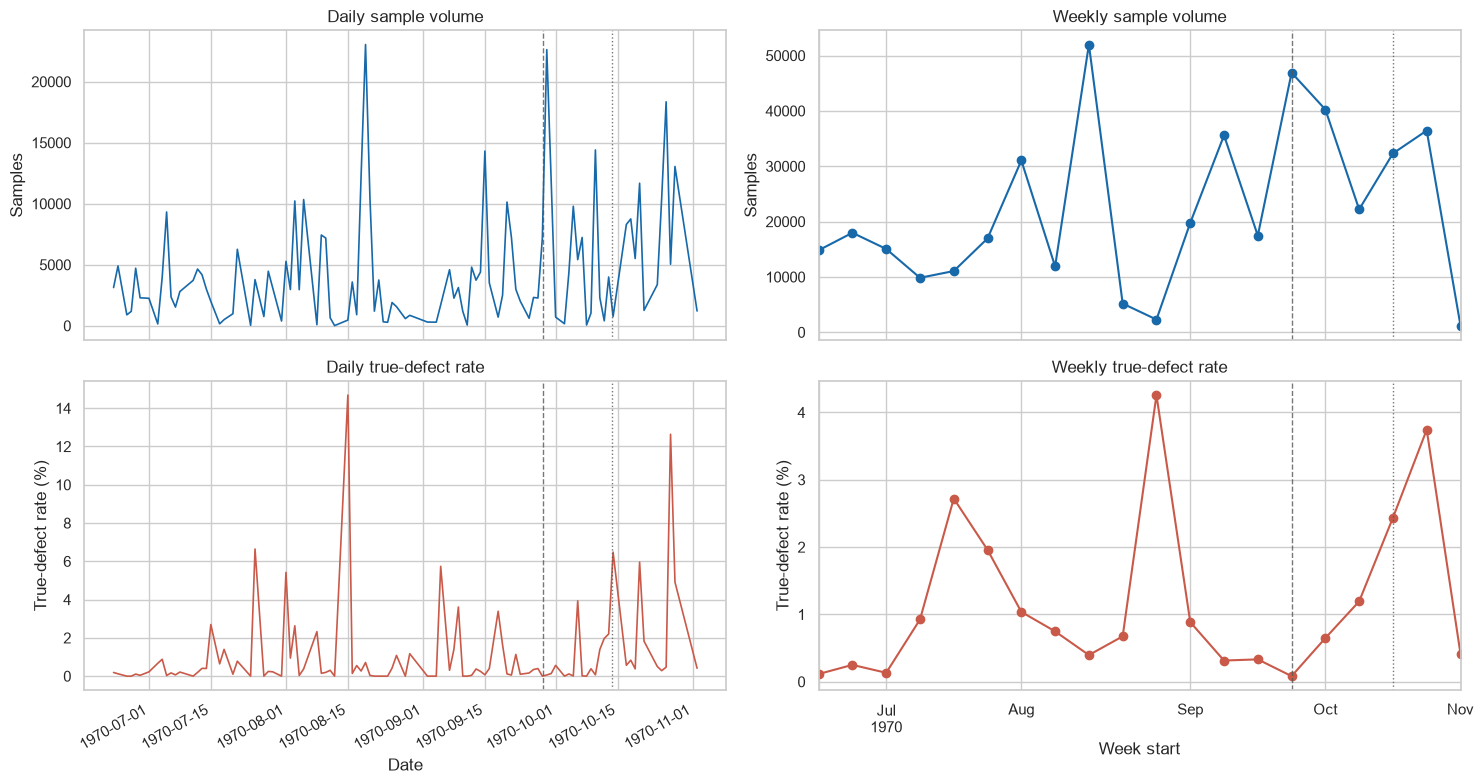

In [4]:
df["date"] = df[PARSED_TIME].dt.floor("D")
df["week_start"] = df["date"] - pd.to_timedelta(df[PARSED_TIME].dt.weekday, unit="D")

daily = (
    df.groupby("date", observed=True)[TARGET]
    .agg(samples="size", true_defects="sum", defect_rate="mean")
    .sort_index()
)
weekly = (
    df.groupby("week_start", observed=True)[TARGET]
    .agg(samples="size", true_defects="sum", defect_rate="mean")
    .sort_index()
)
daily["defect_rate_pct"] = daily["defect_rate"] * 100
weekly["defect_rate_pct"] = weekly["defect_rate"] * 100

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex="col")
daily["samples"].plot(ax=axes[0, 0], color="#1769aa", linewidth=1.2)
axes[0, 0].set_title("Daily sample volume")
axes[0, 0].set_ylabel("Samples")
daily["defect_rate_pct"].plot(ax=axes[1, 0], color="#c95a49", linewidth=1.2)
axes[1, 0].set_title("Daily true-defect rate")
axes[1, 0].set_ylabel("True-defect rate (%)")
axes[1, 0].set_xlabel("Date")
weekly["samples"].plot(ax=axes[0, 1], color="#1769aa", marker="o", linewidth=1.5)
axes[0, 1].set_title("Weekly sample volume")
axes[0, 1].set_ylabel("Samples")
weekly["defect_rate_pct"].plot(ax=axes[1, 1], color="#c95a49", marker="o", linewidth=1.5)
axes[1, 1].set_title("Weekly true-defect rate")
axes[1, 1].set_ylabel("True-defect rate (%)")
axes[1, 1].set_xlabel("Week start")
for axis in axes.ravel():
    axis.axvline(train_end, color="#555555", linestyle="--", linewidth=1, alpha=0.8)
    axis.axvline(validation_end, color="#555555", linestyle=":", linewidth=1, alpha=0.8)
plt.tight_layout()
plt.show()

In [5]:
time_granularity_summary = pd.DataFrame(
    {
        "periods": [len(daily), len(weekly)],
        "minimum_samples": [daily["samples"].min(), weekly["samples"].min()],
        "median_samples": [daily["samples"].median(), weekly["samples"].median()],
        "maximum_samples": [daily["samples"].max(), weekly["samples"].max()],
        "minimum_defect_rate_pct": [daily["defect_rate_pct"].min(), weekly["defect_rate_pct"].min()],
        "median_defect_rate_pct": [daily["defect_rate_pct"].median(), weekly["defect_rate_pct"].median()],
        "maximum_defect_rate_pct": [daily["defect_rate_pct"].max(), weekly["defect_rate_pct"].max()],
    },
    index=["daily_active_periods", "weekly_periods"],
)
display(time_granularity_summary)

,periods,minimum_samples,median_samples,maximum_samples,minimum_defect_rate_pct,median_defect_rate_pct,maximum_defect_rate_pct
daily_active_periods,101,12,"2,993.0000",23046,0.0000,0.2680,14.6868
weekly_periods,20,1208,"17,721.5000",51992,0.0832,0.7110,4.2572


## 5. `inspection_type` 구성비 변화

검사유형별 피처 의미와 타깃 비율이 다르므로 유형 구성비 변화 자체가 전체 분포와 라벨 비율의 변화를 유발할 수 있습니다. 주별 구성비와 분할별 구성비를 함께 확인합니다.

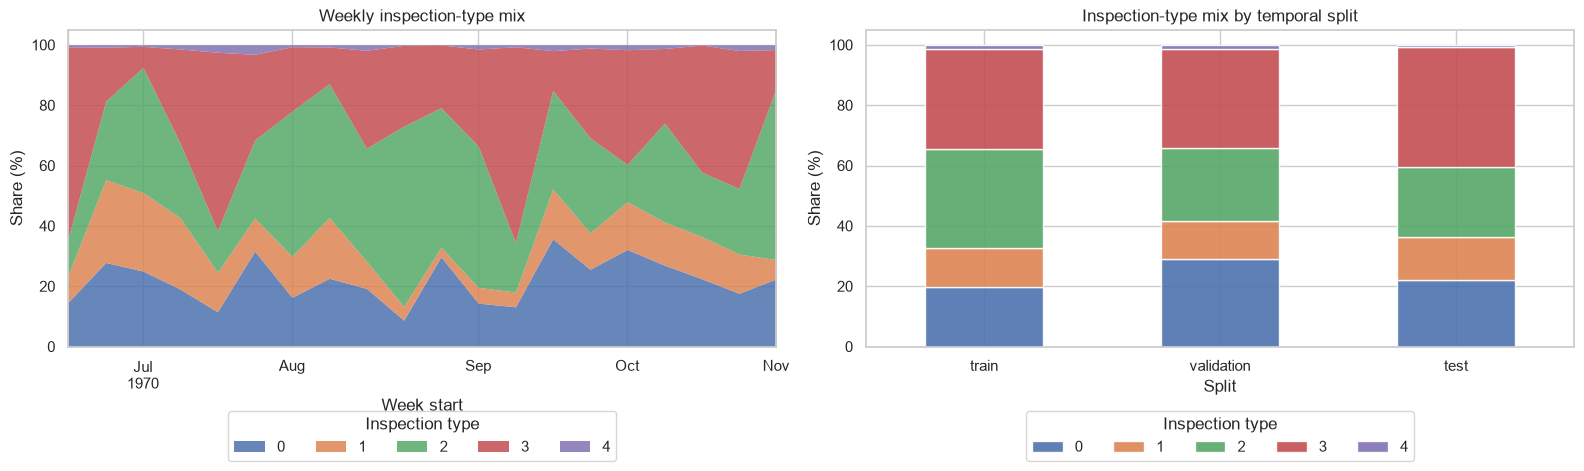

inspection_type,0,1,2,3,4
split,,,,,
train,19.7342,12.9404,32.6977,33.3154,1.3123
validation,28.8988,12.6481,24.1207,32.9146,1.4179
test,22.1358,14.0269,23.3305,39.6800,0.8268


,test_minus_train_pp
inspection_type,
0,2.4016
1,1.0866
2,-9.3671
3,6.3645
4,-0.4855


In [6]:
weekly_type_mix = pd.crosstab(
    df["week_start"], df[TYPE_COLUMN], normalize="index"
).sort_index() * 100
split_type_mix = pd.crosstab(
    df["split"], df[TYPE_COLUMN], normalize="index"
).reindex(["train", "validation", "test"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
weekly_type_mix.plot.area(ax=axes[0], stacked=True, alpha=0.85, linewidth=0)
axes[0].set_title("Weekly inspection-type mix")
axes[0].set_xlabel("Week start")
axes[0].set_ylabel("Share (%)")
axes[0].legend(title="Inspection type", ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
split_type_mix.plot(kind="bar", stacked=True, ax=axes[1], alpha=0.9)
axes[1].set_title("Inspection-type mix by temporal split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Share (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Inspection type", ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.show()
display(split_type_mix)

train_test_mix_change = (split_type_mix.loc["test"] - split_type_mix.loc["train"]).rename("test_minus_train_pp")
display(train_test_mix_change.to_frame())

In [7]:
split_type_target = (
    df.groupby(["split", TYPE_COLUMN], observed=False)[TARGET]
    .agg(samples="size", true_defects="sum", defect_rate="mean")
)
split_type_target["defect_rate_pct"] = split_type_target["defect_rate"] * 100
display(split_type_target[["samples", "true_defects", "defect_rate_pct"]])

samples  true_defects  defect_rate_pct
split      inspection_type                                        
train      0                  52166           107           0.2051
           1                  34207           555           1.6225
           2                  86434           581           0.6722
           3                  88067           645           0.7324
           4                   3469            13           0.3747
validation 0                  25396            16           0.0630
           1                  11115           249           2.2402
           2                  21197            34           0.1604
           3                  28925            24           0.0830
           4                   1246            73           5.8587
test       0                  19491           195           1.0005
           1                  12351           774           6.2667
           2                  20543           731           3.5584
           3                  34939           612           1.7516
           4                    728            13           1.7857

## 6. 검사유형별 첫 구간 대비 마지막 구간 PSI

PSI(Population Stability Index)는 첫 구간인 train을 기준 분포로, 마지막 구간인 test를 비교 분포로 사용합니다. `mapping.json`에 정의된 유형별 유효 피처 중 해당 유형 전체에서 비상수이고 train에서도 두 값 이상인 피처만 계산합니다.

- train의 고유값이 10개 이하이면 인접 고유값의 중점을 경계로 사용합니다.
- 그보다 많으면 train의 10분위 경계를 사용하고 중복 경계를 제거합니다.
- 비율 0의 로그 문제를 피하기 위해 `1e-6`을 적용한 뒤 다시 정규화합니다.
- 탐색적 기준으로 PSI `<0.10`은 낮음, `0.10~0.25`는 중간, `>=0.25`는 큼으로 구분합니다. 이 임계값은 통계적 검정이 아니며 표본 수와 binning에 민감합니다.

In [8]:
def population_stability_index(reference, current, max_bins=10, epsilon=1e-6):
    reference = np.asarray(reference, dtype=float)
    current = np.asarray(current, dtype=float)
    reference = reference[np.isfinite(reference)]
    current = current[np.isfinite(current)]
    if reference.size == 0 or current.size == 0:
        return np.nan, 0

    unique_reference = np.unique(reference)
    if unique_reference.size <= 1:
        return np.nan, 0
    if unique_reference.size <= max_bins:
        interior_edges = (unique_reference[:-1] + unique_reference[1:]) / 2
    else:
        quantiles = np.linspace(0, 1, max_bins + 1)[1:-1]
        interior_edges = np.unique(np.quantile(reference, quantiles))
    edges = np.concatenate(([-np.inf], interior_edges, [np.inf]))

    reference_counts = np.histogram(reference, bins=edges)[0].astype(float)
    current_counts = np.histogram(current, bins=edges)[0].astype(float)
    reference_share = np.clip(reference_counts / reference_counts.sum(), epsilon, None)
    current_share = np.clip(current_counts / current_counts.sum(), epsilon, None)
    reference_share /= reference_share.sum()
    current_share /= current_share.sum()
    psi = np.sum((current_share - reference_share) * np.log(current_share / reference_share))
    return float(psi), len(edges) - 1

In [9]:
psi_rows = []
feature_scope_rows = []
for inspection_type in sorted(df[TYPE_COLUMN].unique()):
    type_group = df.loc[df[TYPE_COLUMN] == inspection_type]
    train_group = type_group.loc[type_group["split"] == "train"]
    test_group = type_group.loc[type_group["split"] == "test"]
    mapped_features = mapping[str(inspection_type)]
    full_nonconstant = [
        feature for feature in mapped_features if type_group[feature].nunique(dropna=False) > 1
    ]
    train_nonconstant = [
        feature for feature in full_nonconstant if train_group[feature].nunique(dropna=False) > 1
    ]
    feature_scope_rows.append(
        {
            "inspection_type": inspection_type,
            "mapped_features": len(mapped_features),
            "full_nonconstant_features": len(full_nonconstant),
            "psi_evaluable_features": len(train_nonconstant),
            "train_rows": len(train_group),
            "test_rows": len(test_group),
        }
    )
    for feature in train_nonconstant:
        psi, bin_count = population_stability_index(
            train_group[feature], test_group[feature], PSI_BINS, PSI_EPSILON
        )
        psi_rows.append(
            {
                "inspection_type": inspection_type,
                "feature": feature,
                "psi": psi,
                "bins": bin_count,
                "train_unique": train_group[feature].nunique(dropna=False),
                "test_unique": test_group[feature].nunique(dropna=False),
            }
        )

feature_scope = pd.DataFrame(feature_scope_rows).set_index("inspection_type")
psi_results = pd.DataFrame(psi_rows)
psi_results["drift_level"] = pd.cut(
    psi_results["psi"],
    bins=[-np.inf, 0.10, 0.25, np.inf],
    labels=["low", "moderate", "large"],
    right=False,
)
assert psi_results["psi"].notna().all()
display(feature_scope)

,mapped_features,full_nonconstant_features,psi_evaluable_features,train_rows,test_rows
inspection_type,,,,,
0,44,37,37,52166,19491
1,52,24,24,34207,12351
2,65,20,20,86434,20543
3,65,19,19,88067,34939
4,21,13,13,3469,728


In [10]:
psi_level_counts = (
    psi_results.groupby(["inspection_type", "drift_level"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["low", "moderate", "large"], fill_value=0)
)
psi_by_type = psi_level_counts.copy()
psi_by_type["evaluated"] = psi_by_type.sum(axis=1)
psi_by_type["median_psi"] = psi_results.groupby("inspection_type")["psi"].median()
psi_by_type["maximum_psi"] = psi_results.groupby("inspection_type")["psi"].max()
display(psi_by_type)

top_psi = psi_results.sort_values("psi", ascending=False).head(20).copy()
display(top_psi.reset_index(drop=True))

drift_level,low,moderate,large,evaluated,median_psi,maximum_psi
inspection_type,,,,,,
0,34,3,0,37,0.0062,0.1091
1,16,5,3,24,0.0566,1.2506
2,13,4,3,20,0.0753,0.5070
3,3,13,3,19,0.1793,0.5925
4,1,1,11,13,0.9890,4.2469


,inspection_type,feature,psi,bins,train_unique,test_unique,drift_level
0,4,inspection_feat7,4.2469,5,5,6,large
1,4,inspection_feat4,2.1428,9,75,31,large
2,4,inspection_feat1,1.6143,10,157,98,large
3,4,inspection_feat32,1.6098,10,243,61,large
4,4,inspection_feat5,1.6098,10,243,61,large
5,4,inspection_feat34,1.4966,8,123,61,large
6,1,inspection_feat7,1.2506,4,84,45,large
7,4,inspection_feat3,0.9890,10,203,134,large
8,4,inspection_feat6,0.7274,10,205,72,large
9,4,inspection_feat33,0.7274,10,205,72,large


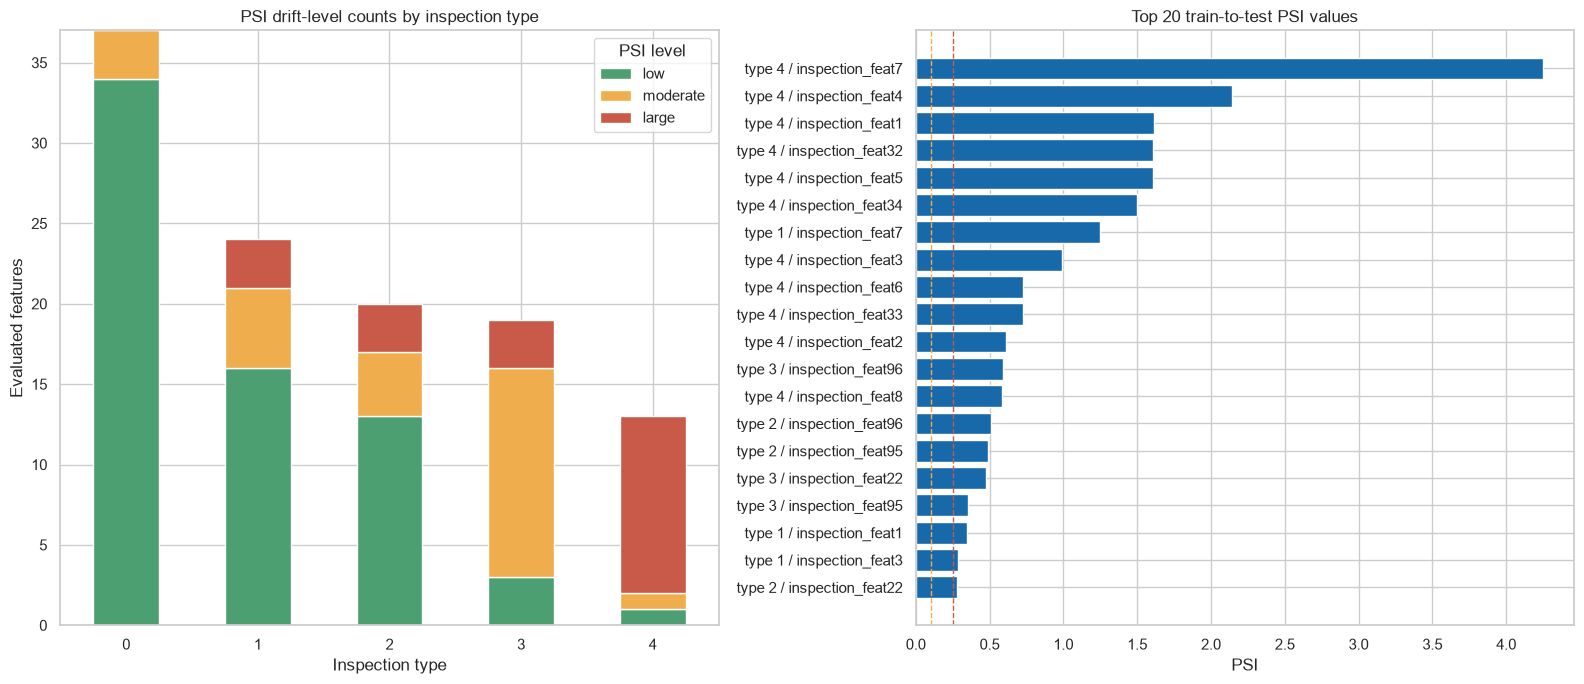

In [11]:
plot_top = top_psi.sort_values("psi").copy()
plot_top["label"] = (
    "type " + plot_top["inspection_type"].astype(str) + " / " + plot_top["feature"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
psi_level_counts.plot(
    kind="bar", stacked=True, ax=axes[0], color=["#4c9f70", "#f0ad4e", "#c95a49"]
)
axes[0].set_title("PSI drift-level counts by inspection type")
axes[0].set_xlabel("Inspection type")
axes[0].set_ylabel("Evaluated features")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="PSI level")

axes[1].barh(plot_top["label"], plot_top["psi"], color="#1769aa")
axes[1].axvline(0.10, color="#f0ad4e", linestyle="--", linewidth=1)
axes[1].axvline(0.25, color="#c95a49", linestyle="--", linewidth=1)
axes[1].set_title("Top 20 train-to-test PSI values")
axes[1].set_xlabel("PSI")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

## 7. 결론 및 다음 단계

아래 결론은 위 집계에서 자동 생성합니다. PSI는 drift 후보를 선별하기 위한 기술통계이며 원인이나 유의성을 단독으로 확정하지 않습니다.

In [12]:
overall_psi_counts = psi_results["drift_level"].value_counts().reindex(
    ["low", "moderate", "large"], fill_value=0
)
largest_mix_type = int(train_test_mix_change.abs().idxmax())
largest_mix_change = float(train_test_mix_change.loc[largest_mix_type])
largest_psi_row = psi_results.loc[psi_results["psi"].idxmax()]
train_rate = float(split_summary.loc["train", "defect_rate_pct"])
test_rate = float(split_summary.loc["test", "defect_rate_pct"])

conclusion = f"""
### 핵심 결과

- 동일 timestamp 그룹을 보존한 시간순 분할은 train **{int(split_summary.loc['train', 'rows']):,}행 ({split_summary.loc['train', 'row_share_pct']:.2f}%)**, validation **{int(split_summary.loc['validation', 'rows']):,}행 ({split_summary.loc['validation', 'row_share_pct']:.2f}%)**, test **{int(split_summary.loc['test', 'rows']):,}행 ({split_summary.loc['test', 'row_share_pct']:.2f}%)**이며 경계를 가로지르는 timestamp 그룹은 0개입니다.
- 전체 true-defect 비율은 train **{train_rate:.3f}%**에서 test **{test_rate:.3f}%**로 **{test_rate / train_rate:.2f}배** 상승했습니다. 이는 시간순 평가가 무작위 분할보다 훨씬 어려울 수 있음을 뜻합니다.
- train 대비 test의 검사유형 구성비 변화 절댓값이 가장 큰 유형은 type **{largest_mix_type}**이며 변화량은 **{largest_mix_change:+.2f}%p**입니다. 유형별 타깃 비율도 함께 변하므로 전체 라벨 변화는 구성비 변화만으로 설명할 수 없습니다.
- 매핑 유효·비상수 피처 **{len(psi_results)}개**의 PSI 중 낮음은 **{int(overall_psi_counts['low'])}개**, 중간은 **{int(overall_psi_counts['moderate'])}개**, 큼은 **{int(overall_psi_counts['large'])}개**입니다.
- 최대 PSI는 type **{int(largest_psi_row['inspection_type'])}**의 `{largest_psi_row['feature']}`에서 **{largest_psi_row['psi']:.3f}**입니다. type 4는 test 표본이 **{int(feature_scope.loc[4, 'test_rows']):,}행**으로 가장 적으므로 큰 PSI를 해석할 때 표본 크기 민감성을 함께 고려해야 합니다.

### 모델링 및 후속 분석 제안

1. 베이스라인 평가는 이 timestamp 그룹 보존 시간순 60/20/20 분할을 사용하고, 전처리 통계와 피처 제거 기준은 train에만 fit합니다.
2. 전체 지표와 함께 split·inspection_type별 PR-AUC, true-defect recall, false-call reduction을 보고해 후기 구간 성능 저하를 분리합니다.
3. PSI가 큰 피처는 주별 PSI 또는 rolling 통계로 변화 시점을 좁히고, 메타 피처·검사유형 구성 변화 및 AOI 설정 변경 가능성과 함께 검토합니다.
4. type 4처럼 표본이 작은 구간은 PSI 순위만으로 제거하지 말고 bootstrap 신뢰구간이나 더 긴 모니터링 창을 추가로 검토합니다.
5. PSI는 단변량 drift만 측정하므로 후속 모델링에서 시간 구간 판별 성능이나 예측 성능 변화로 다변량 drift를 보완합니다.
"""
display(Markdown(conclusion))


### 핵심 결과

- 동일 timestamp 그룹을 보존한 시간순 분할은 train **264,343행 (60.04%)**, validation **87,879행 (19.96%)**, test **88,052행 (20.00%)**이며 경계를 가로지르는 timestamp 그룹은 0개입니다.
- 전체 true-defect 비율은 train **0.719%**에서 test **2.640%**로 **3.67배** 상승했습니다. 이는 시간순 평가가 무작위 분할보다 훨씬 어려울 수 있음을 뜻합니다.
- train 대비 test의 검사유형 구성비 변화 절댓값이 가장 큰 유형은 type **2**이며 변화량은 **-9.37%p**입니다. 유형별 타깃 비율도 함께 변하므로 전체 라벨 변화는 구성비 변화만으로 설명할 수 없습니다.
- 매핑 유효·비상수 피처 **113개**의 PSI 중 낮음은 **67개**, 중간은 **26개**, 큼은 **20개**입니다.
- 최대 PSI는 type **4**의 `inspection_feat7`에서 **4.247**입니다. type 4는 test 표본이 **728행**으로 가장 적으므로 큰 PSI를 해석할 때 표본 크기 민감성을 함께 고려해야 합니다.

### 모델링 및 후속 분석 제안

1. 베이스라인 평가는 이 timestamp 그룹 보존 시간순 60/20/20 분할을 사용하고, 전처리 통계와 피처 제거 기준은 train에만 fit합니다.
2. 전체 지표와 함께 split·inspection_type별 PR-AUC, true-defect recall, false-call reduction을 보고해 후기 구간 성능 저하를 분리합니다.
3. PSI가 큰 피처는 주별 PSI 또는 rolling 통계로 변화 시점을 좁히고, 메타 피처·검사유형 구성 변화 및 AOI 설정 변경 가능성과 함께 검토합니다.
4. type 4처럼 표본이 작은 구간은 PSI 순위만으로 제거하지 말고 bootstrap 신뢰구간이나 더 긴 모니터링 창을 추가로 검토합니다.
5. PSI는 단변량 drift만 측정하므로 후속 모델링에서 시간 구간 판별 성능이나 예측 성능 변화로 다변량 drift를 보완합니다.
